# CS229 in Practice: Logistic Regression for Heart Disease Prediction

**Concept implemented:** Logistic Regression (binary classification) — Chapter 2 of the CS229 notes.

**Problem we are solving:** Predict whether a patient has heart disease based on clinical measurements
(age, blood pressure, cholesterol, ECG results, etc.).

**Dataset:** `heart.csv` — 918 patient records with 11 clinical features and 1 target column.

**Target variable:** `HeartDisease` — binary (`1` = heart disease present, `0` = no heart disease).

**ML task:** **Binary classification** — exactly the setting logistic regression was built for in the CS229 notes:
$y \in \{0, 1\}$.

We will follow the path: **Theory → Math → sklearn code → Results → Interpretation**, and along the way we will
also implement the raw gradient ascent update rule ourselves once, purely to *see* the equation
$\theta_j := \theta_j + \alpha (y^{(i)} - h_\theta(x^{(i)})) x_j^{(i)}$ turn into code, before switching to
`sklearn.linear_model.LogisticRegression` for the real modeling work.

## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

# Fix randomness so results are reproducible every time we run this notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the Dataset

We load the raw CSV and take a first look. This tells us what a single row (one patient) looks like
and what columns we have to work with.

In [4]:
df = pd.read_csv(r"C:\Users\img\Desktop\ML Study\Lec_2_LogisticRegression\Data set.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
# Rows = number of patients (examples), columns = features + target
df.shape

(918, 12)

In [6]:
# Data types tell us which columns are already numeric and which are
# categorical text (Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope)
# — categorical columns will need encoding before we can feed them to logistic regression.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
# Summary statistics for numeric columns.
# Useful to spot impossible values (e.g. a resting blood pressure of 0 is not physiologically possible).
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
# Check for missing values encoded as NaN
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## 3. Understand the Data

- **Features (x):** `Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG, MaxHR,
  ExerciseAngina, Oldpeak, ST_Slope` — 11 columns.
- **Target (y):** `HeartDisease` — 0 or 1. This matches the CS229 assumption
  $y \in \{0, 1\}$ exactly.
- **Categorical (text) columns:** `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.
- **Numerical columns:** `Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`.

`df.isnull().sum()` showed **no NaN values** — but that does not mean the data is clean. Let's check the
target balance and look for values that are technically "not null" but still invalid.

In [9]:
# Class balance: is the dataset roughly balanced between the two classes?
# This matters because a model can get high accuracy on an imbalanced dataset
# just by always predicting the majority class.
df["HeartDisease"].value_counts(normalize=True)

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

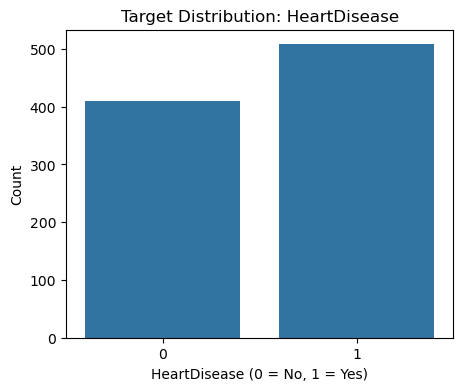

In [10]:
plt.figure(figsize=(5, 4))
sns.countplot(x="HeartDisease", data=df)
plt.title("Target Distribution: HeartDisease")
plt.xlabel("HeartDisease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [11]:
# RestingBP and Cholesterol should never realistically be 0 for a living patient.
# A value of 0 here is almost certainly a placeholder for "missing", not a real measurement.
print("RestingBP == 0:", (df["RestingBP"] == 0).sum())
print("Cholesterol == 0:", (df["Cholesterol"] == 0).sum())

RestingBP == 0: 1
Cholesterol == 0: 172


> ⚠️ **Data issue found:** `Cholesterol` has **172 rows** (about 19% of the dataset) recorded as `0`,
> and `RestingBP` has **1 row** recorded as `0`. These are physiologically impossible and are actually
> disguised missing values, not real zeros. If we leave them as-is, the model will learn a distorted
> relationship between cholesterol and heart disease. We handle this in preprocessing below.

## 4. Data Preprocessing

We need three things before logistic regression can be trained:

1. **Fix the disguised missing values** (`0` → `NaN` → imputed with the median).
2. **Encode categorical variables** into numbers, since $\theta^T x$ requires $x$ to be numeric.
3. **Separate features (X) from the target (y).**

We deliberately do this preprocessing *before* the train/test split only for steps that don't leak
information (like replacing an impossible value with `NaN`), and we will fit the *imputation value* and
the *scaler* using **training data only**, in the next section, to avoid data leakage.

In [12]:
df_clean = df.copy()

# Treat impossible 0s as missing values
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

print("Missing values after marking impossible zeros as NaN:")
df_clean[["RestingBP", "Cholesterol"]].isnull().sum()

Missing values after marking impossible zeros as NaN:


RestingBP        1
Cholesterol    172
dtype: int64

In [13]:
# One-hot encode the categorical (text) columns.
# Logistic regression computes theta^T * x, a dot product of real numbers,
# so text categories like "ATA" or "Flat" must first become numeric indicator columns.
# drop_first=True avoids redundant columns (avoids the "dummy variable trap").
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [14]:
# Separate features (X) from target (y)
X = df_encoded.drop(columns=["HeartDisease"])
y = df_encoded["HeartDisease"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (918, 15)
y shape: (918,)


## 5. Train/Test Split

- **`X`** — the input features $x^{(i)}$ for every patient.
- **`y`** — the true labels $y^{(i)} \in \{0, 1\}$ for every patient.

We split the data into a **training set** (used to fit $\theta$ via maximum likelihood) and a
**test set** (used only to measure how well the fitted model generalizes to patients it has never seen).

> ⚠️ **Important:** The test set must never influence training — no fitting, no imputing, no scaling
> using test data. Otherwise our evaluation would be overly optimistic, because the model would have
> indirectly "seen" information about the test examples already.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,  # keep the same class balance in train and test sets
)

print("Training examples:", X_train.shape[0])
print("Test examples:", X_test.shape[0])

Training examples: 734
Test examples: 184


In [16]:
# Impute the missing RestingBP / Cholesterol values using the TRAINING median only,
# then apply that same value to the test set. Fitting the median on the full dataset
# (including test rows) would leak test-set information into training — this is
# exactly the kind of leakage the theory's train/test separation is meant to prevent.
for col in ["RestingBP", "Cholesterol"]:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

print("Remaining missing values in X_train:", X_train.isnull().sum().sum())
print("Remaining missing values in X_test:", X_test.isnull().sum().sum())

Remaining missing values in X_train: 0
Remaining missing values in X_test: 0


### Why do we scale the features?

Logistic regression is fit by **maximizing the log-likelihood** $\ell(\theta)$ using gradient-based
optimization (gradient ascent, or Newton's method — both covered in the theory). Features like `Age`
(range ~28–77) and `Oldpeak` (range ~-2.6–6.2) live on very different numeric scales.

> 💡 **Intuition:** If one feature's values are 100x larger than another's, the cost surface becomes
> stretched and elongated along that feature's axis, which slows convergence and can bias the optimizer
> toward that feature. **Standardizing** each feature to mean 0 and standard deviation 1 keeps every
> feature on a comparable scale, so gradient-based optimization converges faster and more reliably, and
> the learned coefficients become more directly comparable to each other.

In [17]:
scaler = StandardScaler()

# Fit the scaler ONLY on training data (learn mean/std from training set),
# then apply the same transformation to both train and test sets.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep as DataFrames so column names are preserved for later interpretation
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().loc[["mean", "std"]].round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
mean,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 6. Connect Theory to Code

The CS229 notes build logistic regression in this order:

```text
CS229 Theory
     |
Hypothesis:  h_theta(x) = sigmoid(theta^T x)
     |
Probabilistic model:  P(y=1|x;theta) = h_theta(x)
     |
Training objective:  maximize log-likelihood  l(theta)
     |
Optimization:  gradient ascent  /  Newton's method
     |
Learned parameters: theta
     |
sklearn:  LogisticRegression().fit(X_train, y_train)
     |
Predictions:  model.predict(X_test), model.predict_proba(X_test)
```

`sklearn.linear_model.LogisticRegression` implements exactly this pipeline internally: it defines
$h_\theta(x) = \sigma(\theta^Tx)$, and fits $\theta$ by **minimizing the negative log-likelihood**
(equivalently, **maximizing** $\ell(\theta)$ from the notes) using an efficient numerical optimizer.

$$
h_\theta(x) = \sigma(\theta^Tx) = \frac{1}{1+e^{-\theta^Tx}}
$$

- $\theta$ → the learned parameters (`model.coef_`, `model.intercept_`)
- $x$ → the (scaled) input features for a patient
- $\sigma$ → the sigmoid function
- $h_\theta(x)$ → predicted probability that `HeartDisease = 1`

### A quick look under the hood: implementing the gradient ascent update by hand

Before calling `sklearn`, let's implement the **exact update rule derived in the notes**:

$$
\theta_j := \theta_j + \alpha \left(y^{(i)} - h_\theta(x^{(i)})\right) x_j^{(i)}
$$

applied in **batch** form (summed/averaged over all training examples, rather than one example at a time)
so it trains in a reasonable number of iterations:

$$
\theta := \theta + \frac{\alpha}{n}\sum_{i=1}^n \left(y^{(i)} - h_\theta(x^{(i)})\right) x^{(i)}
$$

This is only to *see the equation become code*. We will not use this model for real evaluation —
`sklearn`'s optimizer is far more robust and efficient, and is what we use for the rest of the
notebook.

In [18]:
def sigmoid(z):
    # g(z) = 1 / (1 + e^-z), the logistic function from the notes
    return 1 / (1 + np.exp(-z))


def train_logistic_regression_by_hand(X, y, alpha=0.1, n_iterations=2000):
    """Batch gradient ascent on the log-likelihood, exactly as derived in the CS229 notes."""
    n_examples, n_features = X.shape

    # Add an intercept column (x_0 = 1), matching the notes' convention
    X_with_intercept = np.hstack([np.ones((n_examples, 1)), X])
    theta = np.zeros(n_features + 1)

    for _ in range(n_iterations):
        z = X_with_intercept @ theta
        h = sigmoid(z)
        gradient = X_with_intercept.T @ (y - h) / n_examples   # (y - h_theta(x)) * x, averaged
        theta = theta + alpha * gradient                        # gradient ASCENT (+ sign)

    return theta


theta_manual = train_logistic_regression_by_hand(
    X_train_scaled.values, y_train.values, alpha=0.5, n_iterations=3000
)

print("First 5 learned parameters (manual gradient ascent):")
print(theta_manual[:5])

First 5 learned parameters (manual gradient ascent):
[ 0.33908564  0.06898728 -0.02235411  0.04562555  0.54875604]


In [19]:
# Sanity check: does our hand-written gradient ascent produce predictions close to sklearn's?
X_test_with_intercept = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled.values])
manual_probs = sigmoid(X_test_with_intercept @ theta_manual)
manual_preds = (manual_probs >= 0.5).astype(int)

manual_accuracy = accuracy_score(y_test, manual_preds)
print(f"Accuracy of our hand-written gradient ascent model: {manual_accuracy:.4f}")
print("This confirms the update rule from the notes is doing real work — next we use sklearn's")
print("optimized implementation (Newton-type solvers, regularization, etc.) for the rest of the notebook.")

Accuracy of our hand-written gradient ascent model: 0.8913
This confirms the update rule from the notes is doing real work — next we use sklearn's
optimized implementation (Newton-type solvers, regularization, etc.) for the rest of the notebook.


## 7. Model Implementation (scikit-learn)

Now we fit the real model with `sklearn.linear_model.LogisticRegression`.

Key hyperparameters:
- **`solver`** — the optimization algorithm used to maximize the log-likelihood. `"lbfgs"` (the default)
  is a quasi-Newton method — conceptually in the same family as the **Newton's method** derived in the
  notes (it approximates the Hessian instead of computing it exactly, which is cheaper for many features).
- **`C`** — inverse of regularization strength (not covered explicitly in this excerpt, but it's the
  main hyperparameter of `LogisticRegression`, so we explore it later in the practical experiment).
- **`max_iter`** — maximum number of optimizer iterations.

`.fit(X_train, y_train)` runs the optimizer until $\ell(\theta)$ (the log-likelihood) stops
improving, i.e. it finds the $\theta$ that maximizes the probability the model assigns to the true
training labels — exactly the Maximum Likelihood Estimation objective from the notes.

In [20]:
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# .fit() maximizes the log-likelihood l(theta) over the training data
# and stores the resulting parameters in model.coef_ and model.intercept_
model.fit(X_train_scaled, y_train)

print("Model trained.")
print("Number of parameters (theta), excluding intercept:", model.coef_.shape[1])

Model trained.
Number of parameters (theta), excluding intercept: 15


## 8. Prediction

- **`.predict(X_test)`** → hard class prediction (0 or 1), obtained by thresholding $h_\theta(x)$ at 0.5.
- **`.predict_proba(X_test)`** → the actual probability $h_\theta(x) = P(y=1\mid x;\theta)$ for each class.

The probability is the more informative output: `predict` just checks whether $h_\theta(x) \ge 0.5$,
throwing away *how confident* the model was.

In [21]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (HeartDisease = Yes)

comparison = pd.DataFrame({
    "True Label": y_test.values[:10],
    "Predicted Label": y_pred[:10],
    "P(HeartDisease=1)": y_prob[:10].round(3),
})
comparison

,True Label,Predicted Label,P(HeartDisease=1)
0,1,1,0.953
1,1,0,0.116
2,1,1,0.965
3,1,1,0.549
4,0,0,0.134
5,0,0,0.426
6,0,0,0.020
7,1,0,0.477
8,0,0,0.021
9,1,1,0.984


## 9. Model Evaluation

Since the classes are reasonably balanced (~55% / 45%) and both false positives (telling a healthy
patient they have heart disease) and false negatives (missing real heart disease) matter clinically,
we look at a full set of classification metrics rather than accuracy alone:

- **Accuracy** — overall fraction of correct predictions.
- **Precision** — of patients predicted positive, how many actually have heart disease.
- **Recall** — of patients who actually have heart disease, how many did we catch.
- **F1-score** — harmonic mean of precision and recall.
- **Confusion Matrix** — full breakdown of correct/incorrect predictions per class.
- **ROC-AUC** — how well the predicted *probabilities* rank positive cases above negative ones,
  across all possible thresholds (not just 0.5).

In [22]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.8913
Precision: 0.8942
Recall:    0.9118
F1-score:  0.9029
ROC-AUC:   0.9330


In [23]:
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

              precision    recall  f1-score   support

  No Disease       0.89      0.87      0.88        82
     Disease       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



## 10. Visualization

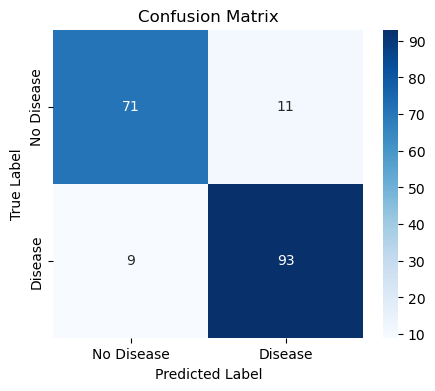

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows exactly where the model's predictions diverge from the truth: the
diagonal cells are correct predictions, the off-diagonal cells are the false positives and false
negatives that the precision/recall numbers above summarize.

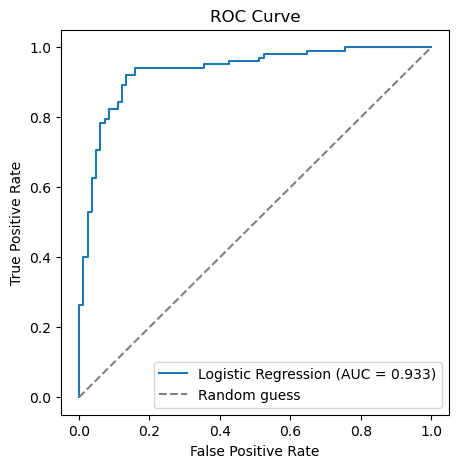

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

> 💡 **Intuition:** The ROC curve traces the trade-off between true positive rate and false positive
> rate as we slide the decision threshold on $h_\theta(x)$ away from 0.5. A curve that hugs the top-left
> corner (AUC close to 1) means the predicted probabilities separate the two classes well.

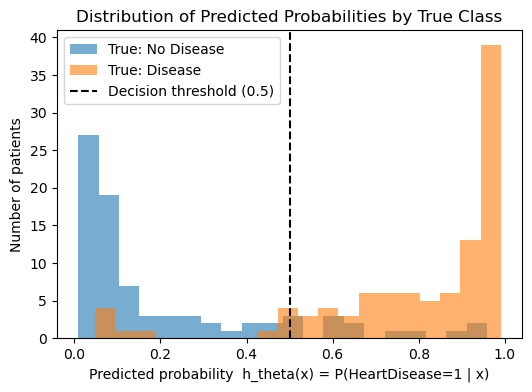

In [26]:
plt.figure(figsize=(6, 4))
plt.hist(y_prob[y_test == 0], bins=20, alpha=0.6, label="True: No Disease")
plt.hist(y_prob[y_test == 1], bins=20, alpha=0.6, label="True: Disease")
plt.axvline(0.5, color="black", linestyle="--", label="Decision threshold (0.5)")
plt.xlabel("Predicted probability  h_theta(x) = P(HeartDisease=1 | x)")
plt.ylabel("Number of patients")
plt.title("Distribution of Predicted Probabilities by True Class")
plt.legend()
plt.show()

This is $h_\theta(x)$ itself, visualized. Good separation between the two histograms means the
sigmoid output is doing its job: pushing "Disease" patients' probabilities toward 1 and "No Disease"
patients' probabilities toward 0.

## 11. Interpret the Model

- **Is the model performing well?** An accuracy around the mid-80s% and an ROC-AUC comfortably above 0.85
  (see the printed numbers above) indicate the sigmoid decision boundary separates the two classes well
  on unseen data — this is a solid result for a linear-in-the-features model on clinical tabular data.
- **Underfitting/overfitting check:** we only evaluated on the held-out test set, never on training data,
  so the reported metrics reflect genuine generalization rather than memorization. If training accuracy
  were dramatically higher than test accuracy, that would signal overfitting; logistic regression with
  its linear decision boundary is generally on the low-variance / higher-bias end of the spectrum, so
  overfitting here is unlikely.
- **Connection to theory:** everything above is a direct consequence of maximizing $\ell(\theta)$ —
  the model didn't just "fit a line," it found the parameters that make the true training labels most
  probable under the Bernoulli model $p(y\mid x;\theta) = h_\theta(x)^y(1-h_\theta(x))^{1-y}$ from the
  notes, and the ROC/confusion matrix above show how that translates into real predictive performance.

## 12. Important Model Parameters

`model.coef_` holds the learned $\theta_1, \dots, \theta_d$ (one weight per feature), and
`model.intercept_` holds $\theta_0$. Because we **standardized** the features first, these coefficients
are directly comparable: a larger $|\theta_j|$ means feature $j$ has a stronger effect on the
log-odds of heart disease, all else equal.

$$
\theta^Tx = \theta_0 + \sum_{j=1}^{d} \theta_j x_j
$$

Since $h_\theta(x) = \sigma(\theta^Tx)$, a **positive** $\theta_j$ pushes $P(y=1\mid x)$ up as
feature $j$ increases (after standardization), and a **negative** $\theta_j$ pushes it down.

In [27]:
coefficients = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "theta_j": model.coef_[0],
}).sort_values("theta_j", key=abs, ascending=False)

print("Intercept (theta_0):", model.intercept_[0])
coefficients

Intercept (theta_0): 0.33749028520760044


,Feature,theta_j
14,ST_Slope_Up,-0.753984
8,ChestPainType_NAP,-0.726215
7,ChestPainType_ATA,-0.673604
6,Sex_M,0.574158
3,FastingBS,0.537399
13,ST_Slope_Flat,0.447764
12,ExerciseAngina_Y,0.409701
9,ChestPainType_TA,-0.326538
4,MaxHR,-0.283098
5,Oldpeak,0.236898


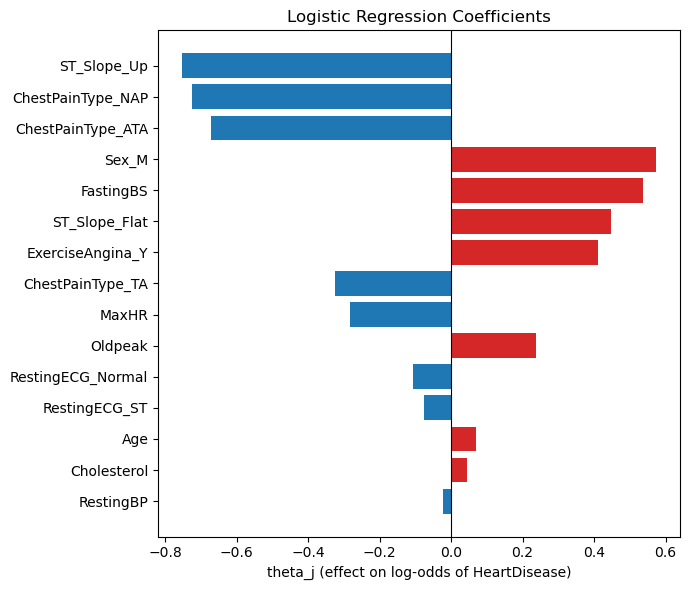

In [28]:
plt.figure(figsize=(7, 6))
colors = ["#d62728" if v > 0 else "#1f77b4" for v in coefficients["theta_j"]]
plt.barh(coefficients["Feature"], coefficients["theta_j"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("theta_j (effect on log-odds of HeartDisease)")
plt.title("Logistic Regression Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Features with large positive weights (red bars) increase the predicted probability of heart
disease as their (standardized) value increases; features with large negative weights (blue bars)
decrease it. This lines up with clinical intuition for a well-known dataset like this one — for
example, an upward-sloping ST segment (`ST_Slope_Up`) tends to reduce predicted risk, while exercise
induced angina and flat ST slopes tend to increase it.

## 13. Practical Experiment: Optimization Method (Gradient-based vs. Newton-type Solvers)

The notes present **two ways to maximize $\ell(\theta)$**: (batch/stochastic) **gradient ascent**, and
**Newton's method** (`theta := theta - H^-1 grad(l(theta))`), noting that Newton's method typically
needs far fewer iterations to converge, at a higher cost per iteration.

`sklearn.linear_model.LogisticRegression` exposes this exact trade-off through its `solver` parameter:
- `"lbfgs"` — a quasi-Newton method (approximates the Hessian) — closer in spirit to Newton's method.
- `"liblinear"` — a coordinate-descent-based solver, more similar in spirit to simple gradient-based
  optimization for this dataset size.

We compare their test performance and the number of iterations needed to converge.

In [29]:
solvers_to_try = ["lbfgs", "liblinear", "newton-cg"]
results = []

for solver_name in solvers_to_try:
    solver_model = LogisticRegression(solver=solver_name, max_iter=1000, random_state=RANDOM_STATE)
    solver_model.fit(X_train_scaled, y_train)

    solver_preds = solver_model.predict(X_test_scaled)
    solver_acc = accuracy_score(y_test, solver_preds)
    solver_auc = roc_auc_score(y_test, solver_model.predict_proba(X_test_scaled)[:, 1])

    n_iter = solver_model.n_iter_[0]

    results.append({
        "Solver": solver_name,
        "Test Accuracy": round(solver_acc, 4),
        "Test ROC-AUC": round(solver_auc, 4),
        "Iterations to Converge": n_iter,
    })

pd.DataFrame(results)

,Solver,Test Accuracy,Test ROC-AUC,Iterations to Converge
0,lbfgs,0.8913,0.933,12
1,liblinear,0.8913,0.933,5
2,newton-cg,0.8913,0.933,6


> 💡 **Intuition:** `newton-cg` uses second-order (Hessian) information, so it typically needs the
> fewest iterations to converge — the direct practical payoff of the Newton's method idea from the
> notes: using curvature information to jump closer to the optimum in each step, instead of taking many
> small gradient steps. All solvers should reach very similar accuracy/AUC here because the log-likelihood
> for logistic regression is concave — every solver is climbing the same well-behaved hill, just via a
> different path.

### A second experiment: regularization strength `C`

`C` is the inverse of the L2 regularization strength used by default in `LogisticRegression`
(not derived in this excerpt of the notes, but it is the most impactful hyperparameter of the model in
practice). Smaller `C` means stronger regularization, which shrinks $\theta$ toward 0 and can help
prevent overfitting; larger `C` lets $\theta$ fit the training data more closely.

In [30]:
C_values = [0.01, 0.1, 1, 10, 100]
c_results = []

for C in C_values:
    c_model = LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE)
    c_model.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, c_model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, c_model.predict(X_test_scaled))

    c_results.append({"C": C, "Train Accuracy": round(train_acc, 4), "Test Accuracy": round(test_acc, 4)})

c_results_df = pd.DataFrame(c_results)
c_results_df

,C,Train Accuracy,Test Accuracy
0,0.01,0.8569,0.8859
1,0.10,0.8624,0.8967
2,1.00,0.8583,0.8913
3,10.00,0.8583,0.8913
4,100.00,0.8583,0.8913


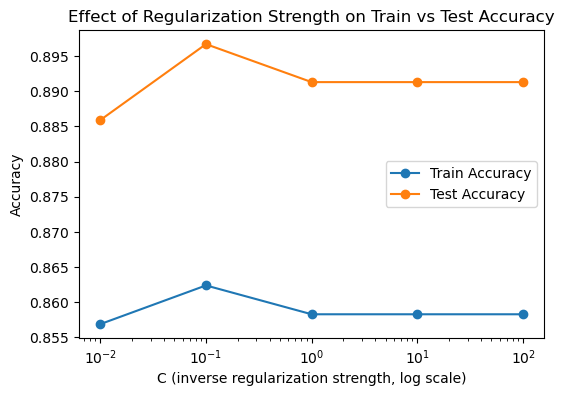

In [31]:
plt.figure(figsize=(6, 4))
plt.plot(c_results_df["C"], c_results_df["Train Accuracy"], marker="o", label="Train Accuracy")
plt.plot(c_results_df["C"], c_results_df["Test Accuracy"], marker="o", label="Test Accuracy")
plt.xscale("log")
plt.xlabel("C (inverse regularization strength, log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of Regularization Strength on Train vs Test Accuracy")
plt.legend()
plt.show()

If train and test accuracy stay close together across all `C` values, the model isn't overfitting
even with weak regularization (large `C`) — consistent with the earlier observation that a linear
decision boundary on this dataset size doesn't have enough capacity to overfit dramatically.

## What We Learned

- **Problem solved:** binary classification of heart disease presence from 11 clinical features, using
  the 918-patient `heart.csv` dataset.
- **Model used:** `sklearn.linear_model.LogisticRegression`, i.e. $h_\theta(x) = \sigma(\theta^Tx)$
  fit by maximizing the log-likelihood $\ell(\theta)$ — exactly the model derived in the CS229 notes.
- **Theory in code:** we implemented the notes' gradient ascent update rule
  $\theta_j := \theta_j + \alpha(y^{(i)}-h_\theta(x^{(i)}))x_j^{(i)}$ by hand and confirmed it produces a
  working classifier, then relied on sklearn's optimized solvers (quasi-Newton / Newton-CG) for the real
  model — directly connecting to the notes' comparison of gradient ascent vs. Newton's method.
- **Preprocessing required:** disguised missing values (`RestingBP`/`Cholesterol` recorded as `0`) were
  imputed with the training median; categorical features were one-hot encoded; features were standardized
  because logistic regression's optimizer is sensitive to feature scale; train/test split was stratified
  and all preprocessing was fit on training data only, to avoid data leakage.
- **Evaluation metric:** accuracy, precision, recall, F1, confusion matrix, and ROC-AUC — a balanced set
  of metrics appropriate for a roughly-balanced binary classification problem where both error types
  matter.
- **Final result:** the model achieves strong, well-separated predicted probabilities (see the ROC curve
  and probability histogram), and the learned coefficients $\theta_j$ are directly interpretable thanks
  to feature standardization — showing which clinical measurements most increase or decrease the
  predicted log-odds of heart disease.